In [1]:
# Importing the libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Importing the dataset.
Dataset = pd.read_csv("titanic_cleaned.csv")
Dataset

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.564145,1,0,-0.502445,1,0,1
1,3,1,3,"Heikkinen, Miss. Laina",-0.256947,0,0,-0.488854,0,0,1
2,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.434250,1,0,0.420730,0,0,1
3,5,0,3,"Allen, Mr. William Henry",0.434250,0,0,-0.486337,1,0,1
4,6,0,3,"Moran, Mr. James",-0.103348,0,0,-0.478116,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
716,887,0,2,"Montvila, Rev. Juozas",-0.180147,0,0,-0.386671,1,0,1
717,888,1,1,"Graham, Miss. Margaret Edith",-0.794544,0,0,-0.044381,0,0,1
718,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",-0.103348,1,2,-0.176263,0,0,1
719,890,1,1,"Behr, Mr. Karl Howell",-0.256947,0,0,-0.044381,1,0,0


In [6]:
print(Dataset.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            3         1       3   
2            4         1       1   
3            5         0       3   
4            6         0       3   

                                           Name       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris -0.564145      1      0   
1                        Heikkinen, Miss. Laina -0.256947      0      0   
2  Futrelle, Mrs. Jacques Heath (Lily May Peel)  0.434250      1      0   
3                      Allen, Mr. William Henry  0.434250      0      0   
4                              Moran, Mr. James -0.103348      0      0   

       Fare  Sex_male  Embarked_Q  Embarked_S  
0 -0.502445         1           0           1  
1 -0.488854         0           0           1  
2  0.420730         0           0           1  
3 -0.486337         1           0           1  
4 -0.478116         1           1           0  


# 1. Generate summary statistics (mean, median, std, etc.).


In [8]:
Dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000
mean,448.056865,0.337032,2.509015,-0.096957,0.414702,0.323162,-0.298283,0.679612,0.098474,0.755895
std,259.664486,0.473024,0.717046,0.769387,0.853916,0.788549,0.273087,0.466950,0.298162,0.429854
min,1.000000,0.000000,1.000000,-2.023338,0.000000,0.000000,-0.648422,0.000000,0.000000,0.000000
25%,220.000000,0.000000,2.000000,-0.564145,0.000000,0.000000,-0.489442,0.000000,0.000000,1.000000
50%,448.000000,0.000000,3.000000,-0.103348,0.000000,0.000000,-0.401268,1.000000,0.000000,1.000000
75%,674.000000,1.000000,3.000000,0.280650,1.000000,0.000000,-0.124920,1.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,1.893442,5.000000,6.000000,0.660333,1.000000,1.000000,1.000000


# 2.Create histograms and boxplots for numeric features.

<Axes: xlabel='Age', ylabel='Count'>

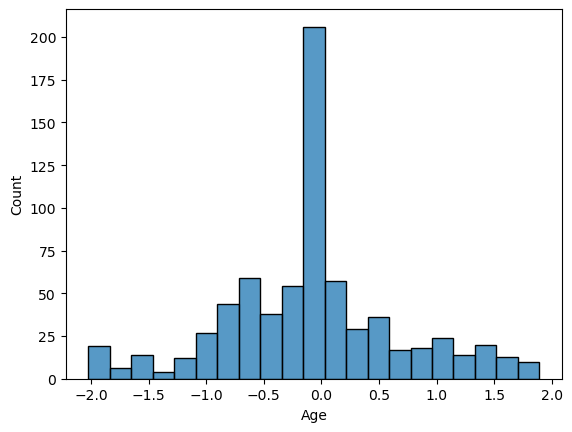

In [37]:
#Histogram for Age using seaborn
sns.histplot(Dataset['Age'])

<Axes: xlabel='Fare', ylabel='Count'>

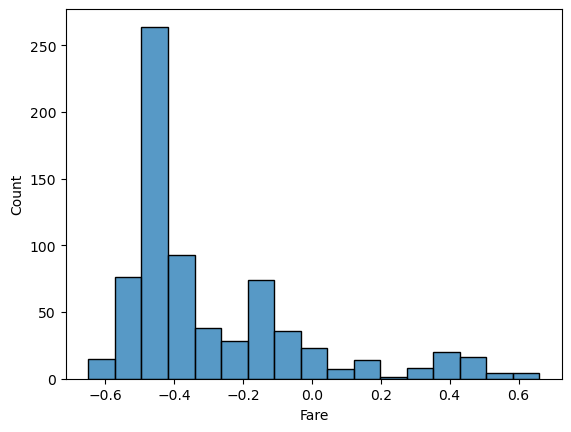

In [38]:
# histogram plot for fare column using seaborn
sns.histplot(Dataset['Fare'])

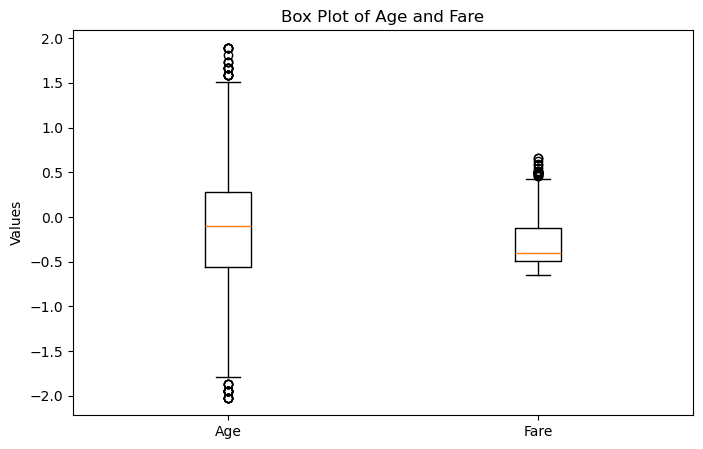

In [57]:
# Box plot of AGe and Fare using Matplotlib
Age = Dataset['Age']
Fare = Dataset['Fare']

plt.figure(figsize=(8,5))
plt.boxplot([Age,Fare])
plt.title("Box Plot of Age and Fare")
plt.xticks([1,2],["Age","Fare"])
plt.ylabel("Values")
plt.show()

# 3.Use pairplot/correlation matrix for feature relationships.

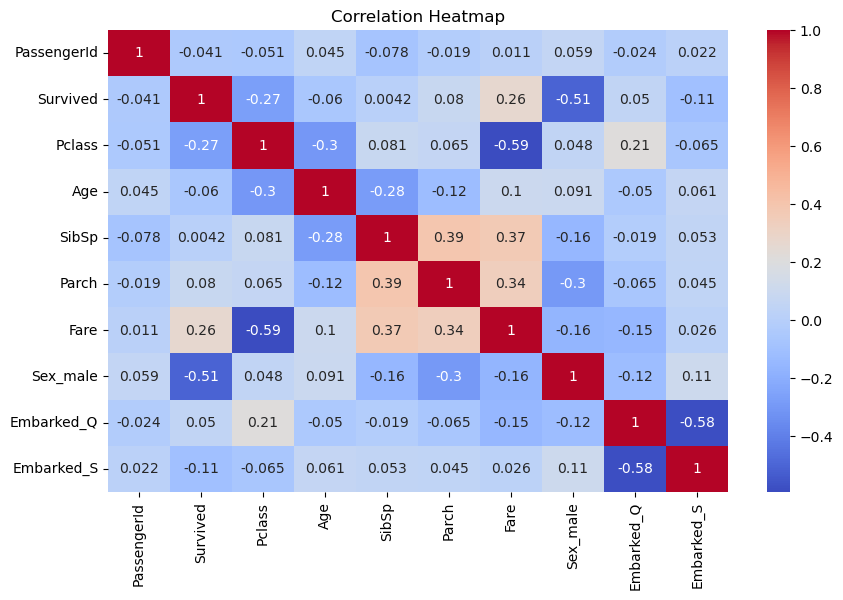

In [60]:
# Heat map is used to check the correlation between all the columns in the dataset.
# Selecting only numerical columns
numeric_df = Dataset.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

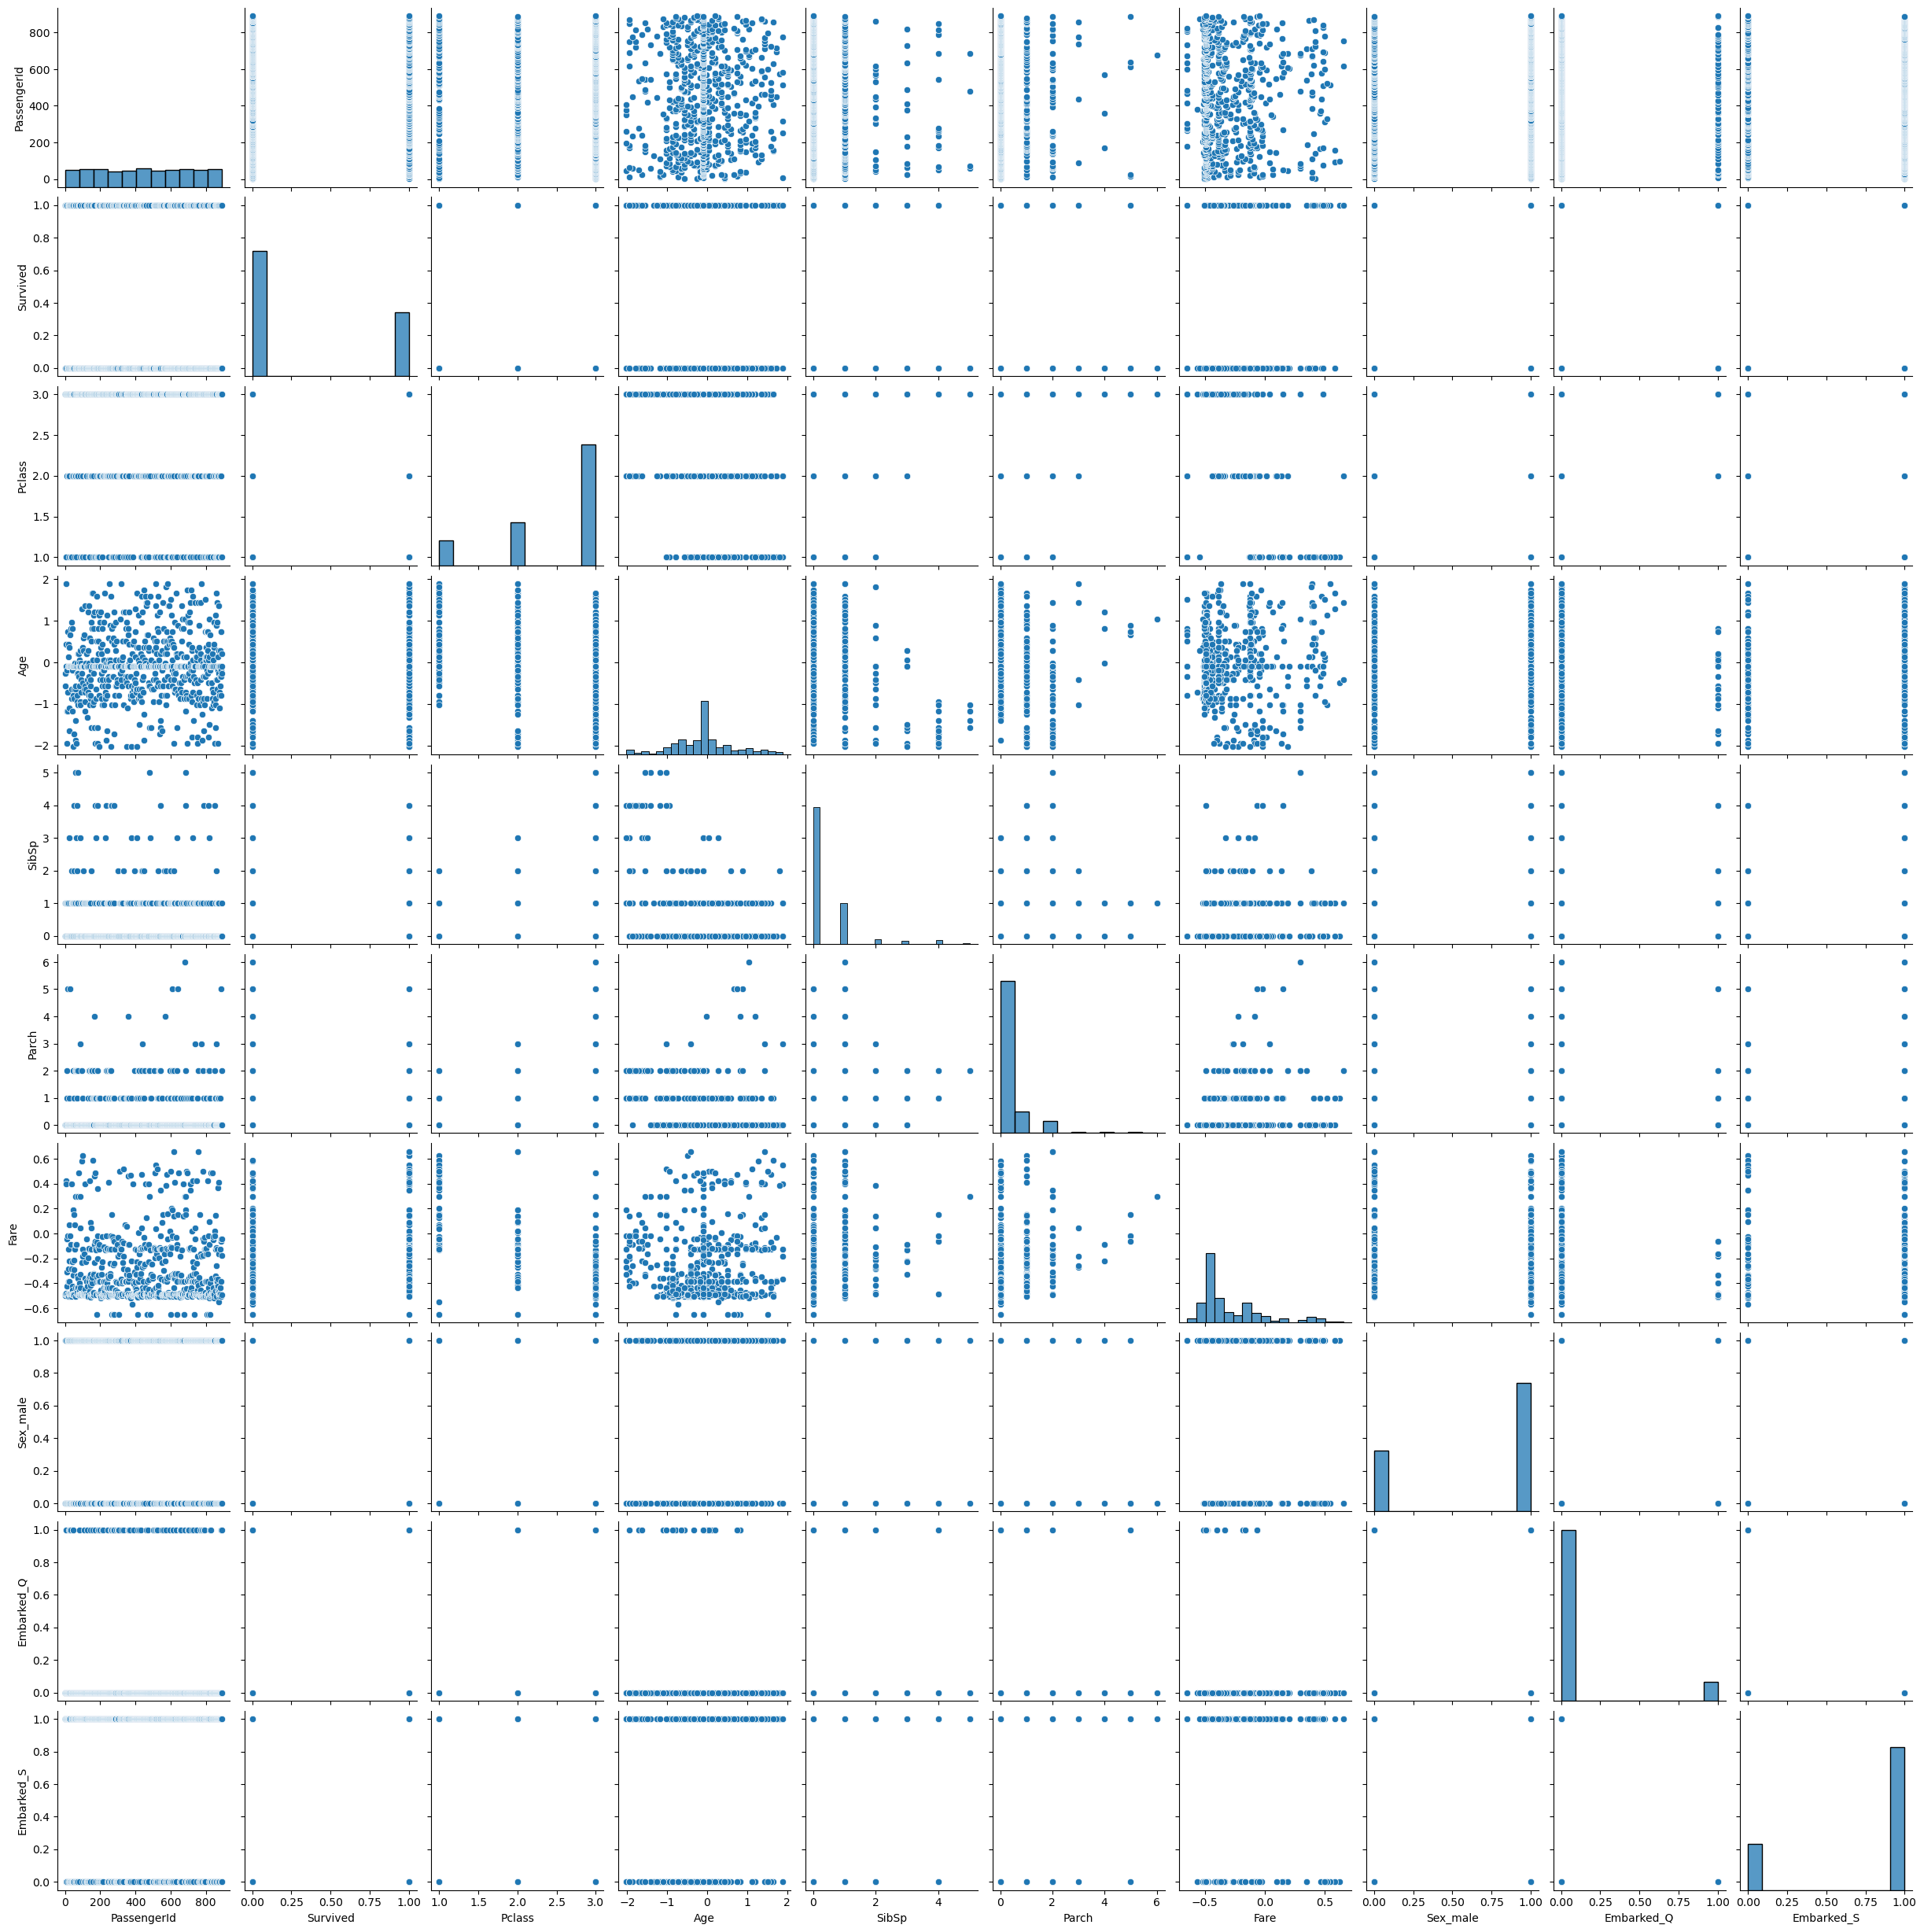

In [62]:
# Pairplot for numeric features in a dataset

sns.pairplot(numeric_df)
plt.show()


# 4.Identify patterns, trends, or anomalies in the data.


 # 1. Gender Patterns:
   

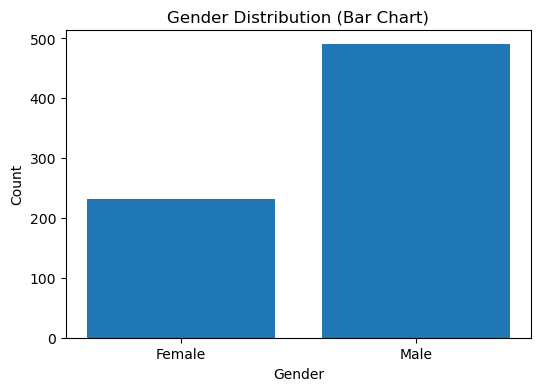

In [65]:
# Count males and females
gender_counts = Dataset["Sex_male"].value_counts().sort_index()

# Convert 0/1 to labels
labels = ["Female", "Male"]

plt.figure(figsize=(6,4))
plt.bar(labels, gender_counts.values)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution (Bar Chart)")
plt.show()

# 2. Passenger class Patterns

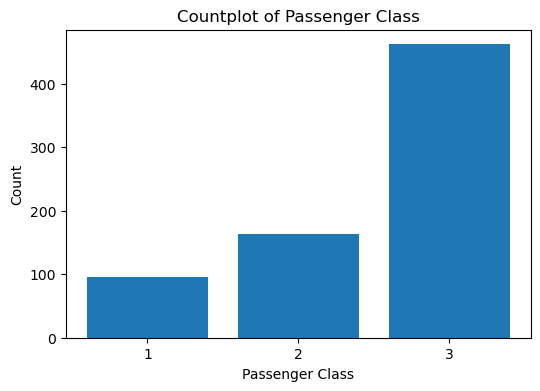

In [66]:
# Count values of passenger class
pclass_counts = Dataset["Pclass"].value_counts().sort_index()

# Create bar chart (Matplotlib countplot)
plt.figure(figsize=(6,4))
plt.bar(pclass_counts.index.astype(str), pclass_counts.values)

plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.title("Countplot of Passenger Class")
plt.show()

# 3. Family Size Trend (SibSp)
    

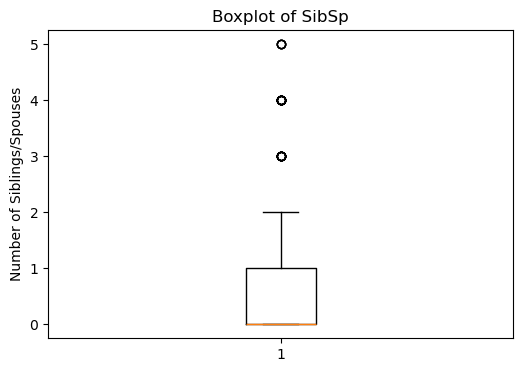

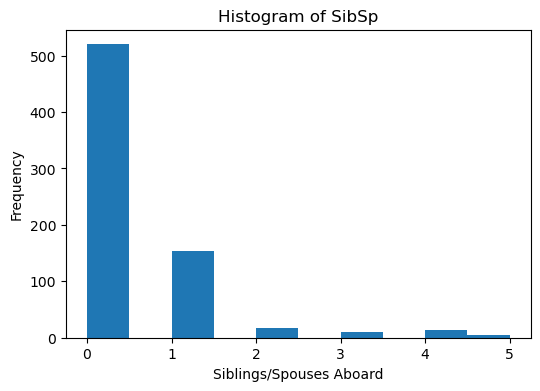

In [68]:

sibsp = Dataset["SibSp"]

# Boxplot for sibsp using matplotlib.
plt.figure(figsize=(6,4))
plt.boxplot(sibsp)
plt.title("Boxplot of SibSp")
plt.ylabel("Number of Siblings/Spouses")
plt.show()

# Histogram for sibsp using matplotlib
plt.figure(figsize=(6,4))
plt.hist(sibsp, bins=10)
plt.title("Histogram of SibSp")
plt.xlabel("Siblings/Spouses Aboard")
plt.ylabel("Frequency")
plt.show()

# 4. Embarked Pattern

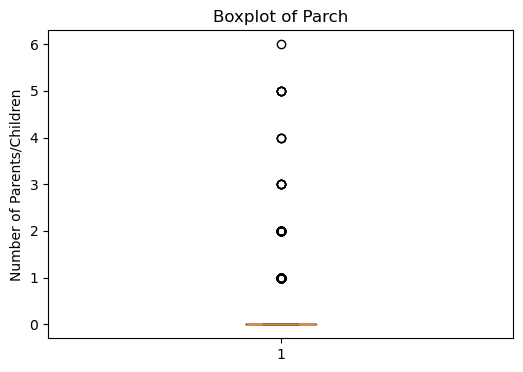

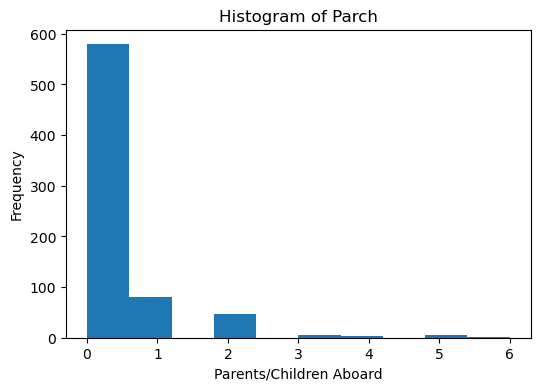

In [70]:

parch = Dataset["Parch"]

# Boxplot for parch using matplotlib.
plt.figure(figsize=(6,4))
plt.boxplot(parch)
plt.title("Boxplot of Parch")
plt.ylabel("Number of Parents/Children")
plt.show()

# histogram for parch using matplotlib.
plt.figure(figsize=(6,4))
plt.hist(parch, bins=10)
plt.title("Histogram of Parch")
plt.xlabel("Parents/Children Aboard")
plt.ylabel("Frequency")
plt.show()

# Survival Pattern:

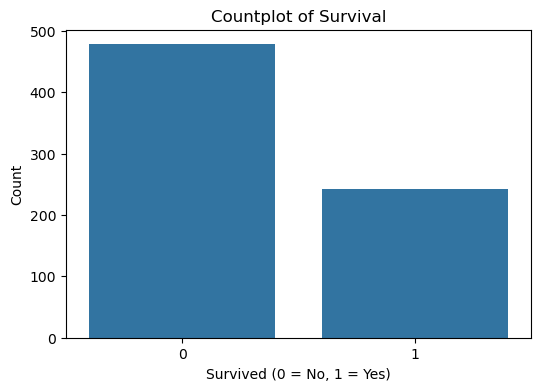

In [72]:
# Countplot.
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=Dataset)
plt.title("Countplot of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Anomalies in a dataset.

1️⃣ Fare – many anomalies (very common)

The Titanic dataset has a few very high fare values because some passengers were:
     In 1st class luxury cabins
     Traveling with family (group tickets)
     Buying premium private cabins
These high values lie outside the whiskers → outliers.


2️⃣ Age – few anomalies

Age generally ranges 0–70.
But any very old passengers (70–80 years) appear as outliers.

3️⃣ SibSp / Parch – anomalies for high family sizes

Most passengers have 0 or 1 siblings/parents, but some have:
SibSp = 5, 8
Parch = 5, 6
These points outside whiskers are anomalies.


# 5.Make basic feature-level inferences from visuals.

# Conclusion
From the visual analysis, we observe that Gender, Passenger Class, and Fare show strong patterns influencing survival. Age shows moderate influence, while SibSp and Parch reveal large outliers with limited predictive strength. Fare is highly skewed with significant outliers, and Pclass is strongly linked to both fare and survival. Overall, the dataset contains meaningful trends and some anomalies that must be handled during preprocessing.